# Random Forest

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("input_data/decision_trees_credit_card.csv")

In [3]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


In [4]:
df.label.value_counts()

0    1373
1     175
Name: label, dtype: int64

## Data Cleaning

In [5]:
df['age']=df['Birthday_count']/-365


In [6]:
df.drop('Birthday_count',axis=1,inplace=True)

In [7]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,age
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,365243,1,0,0,0,NaN,2,1,51.430137
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-586,1,1,1,0,NaN,2,1,37.142466
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-586,1,1,1,0,NaN,2,1,NaN
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-586,1,1,1,0,NaN,2,1,37.142466
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-586,1,1,1,0,NaN,2,1,37.142466


Employed days is the number of days a person has remained employed counting backwards from today. Positive value means the person is unemployed

In [8]:
df['Employed_days']=np.where(df['Employed_days']>0,0,df['Employed_days'])
df['employed_years']=df['Employed_days']/(-365)
df.drop('Employed_days',axis=1,inplace=True)

In [9]:
for i in df.columns:
    print(i,":",df[i].isna().sum())

Ind_ID : 0
GENDER : 7
Car_Owner : 0
Propert_Owner : 0
CHILDREN : 0
Annual_income : 23
Type_Income : 0
EDUCATION : 0
Marital_status : 0
Housing_type : 0
Mobile_phone : 0
Work_Phone : 0
Phone : 0
EMAIL_ID : 0
Type_Occupation : 488
Family_Members : 0
label : 0
age : 22
employed_years : 0


In [10]:
df.Type_Occupation.value_counts(dropna=False)

NaN                      488
Laborers                 268
Core staff               174
Managers                 136
Sales staff              122
Drivers                   86
High skill tech staff     65
Medicine staff            50
Accountants               44
Security staff            25
Cleaning staff            22
Cooking staff             21
Private service staff     17
Low-skill Laborers         9
Secretaries                9
Waiters/barmen staff       5
HR staff                   3
IT staff                   2
Realty agents              2
Name: Type_Occupation, dtype: int64

For categorical variable it is best to define a different category as Missing 

In [11]:
df['Type_Occupation']=df['Type_Occupation'].fillna('Type_Occupation_Missing')
df['GENDER']=df['GENDER'].fillna('Gender_Missing')

Now, for numerical variables, a different approach is required, so filling in the missing values with median

In [12]:
df['Annual_income']=df['Annual_income'].fillna(df['Annual_income'].median())
df['age']=df['age'].fillna(df['age'].median())

In [13]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,age,employed_years
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,1,0,0,0,Type_Occupation_Missing,2,1,51.430137,-0.000000
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,1,0,Type_Occupation_Missing,2,1,37.142466,1.605479
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,1,0,Type_Occupation_Missing,2,1,42.908219,1.605479
3,5009749,F,Y,N,0,166500.0,Commercial associate,Higher education,Married,House / apartment,1,1,1,0,Type_Occupation_Missing,2,1,37.142466,1.605479
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,1,0,Type_Occupation_Missing,2,1,37.142466,1.605479


In [14]:
categorical_variable=df.select_dtypes(include=['object']).columns
for i in categorical_variable:
    a=df[i].value_counts()
    print(i)
    print(a)


GENDER
F                 973
M                 568
Gender_Missing      7
Name: GENDER, dtype: int64
Car_Owner
N    924
Y    624
Name: Car_Owner, dtype: int64
Propert_Owner
Y    1010
N     538
Name: Propert_Owner, dtype: int64
Type_Income
Working                 798
Commercial associate    365
Pensioner               269
State servant           116
Name: Type_Income, dtype: int64
EDUCATION
Secondary / secondary special    1031
Higher education                  426
Incomplete higher                  68
Lower secondary                    21
Academic degree                     2
Name: EDUCATION, dtype: int64
Marital_status
Married                 1049
Single / not married     227
Civil marriage           101
Separated                 96
Widow                     75
Name: Marital_status, dtype: int64
Housing_type
House / apartment      1380
With parents             80
Municipal apartment      53
Rented apartment         21
Office apartment          9
Co-op apartment           5
Name: Housin

In [15]:
df['Mobile_phone'].value_counts()

1    1548
Name: Mobile_phone, dtype: int64

dropping mobile_phone

In [16]:
df.drop('Mobile_phone',axis=1,inplace=True)

## Data preperation

Finding the correlation between the variables and creating a correlation graph

In [17]:
df.drop('Ind_ID',axis=1,inplace=True)

In [18]:
def cat_num_split(df):
    categorical_variables = df.select_dtypes(include=['object', 'string']).columns.tolist()
    df_categorical=df[categorical_variables]
    numerical_variables = df.select_dtypes(include=['number']).columns.tolist()
    df_numerical=df[numerical_variables]
    return df_categorical,df_numerical,categorical_variables,numerical_variables

In [19]:
def corr_graph(df_numerical):
    corr=df_numerical.corr().round(2)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.title("Correlation Heatmap")
    plt.show()

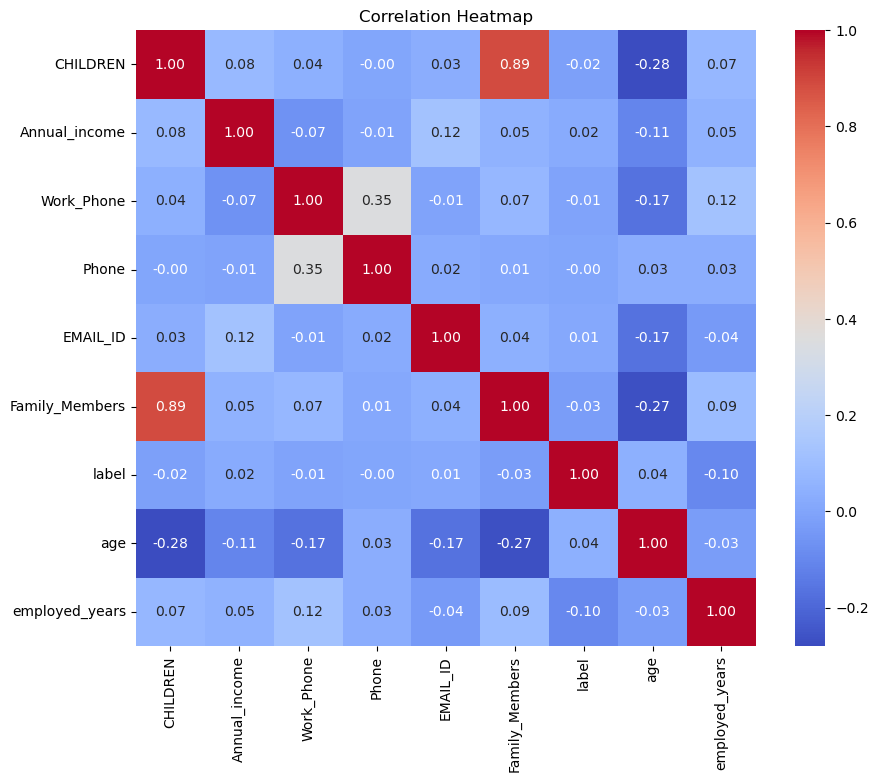

In [20]:
df_categorical,df_numerical,categorical_variables,numerical_variables=cat_num_split(df)
corr_graph(df_numerical)

Here children and family members have high correlation with each other. As children is a subset of family members, dropping the children column

In [21]:
df.drop('CHILDREN',axis=1,inplace=True)

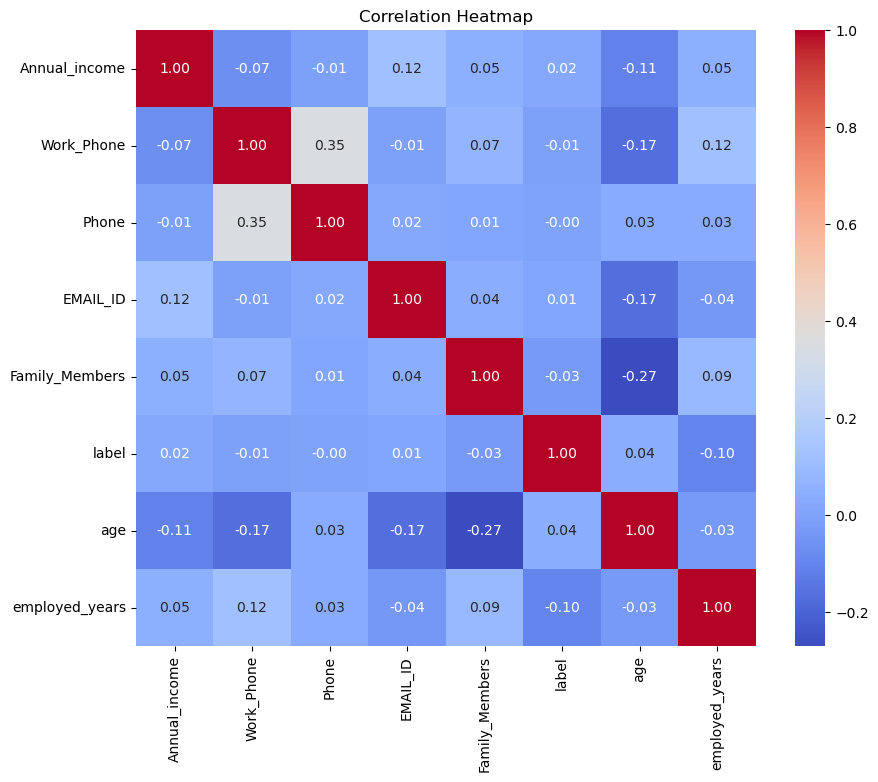

In [22]:
df_categorical,df_numerical,categorical_variables,numerical_variables=cat_num_split(df)
corr_graph(df_numerical)

In [23]:
df_numerical.groupby('label').agg(['mean'])

,Annual_income,Work_Phone,Phone,EMAIL_ID,Family_Members,age,employed_years
,mean,mean,mean,mean,mean,mean,mean
label,,,,,,,
0,190049.142389,0.209031,0.309541,0.091042,2.171886,43.746943,6.301891
1,198720.000000,0.200000,0.308571,0.102857,2.080000,45.378521,4.285276


For numerical variable, plotting box plot

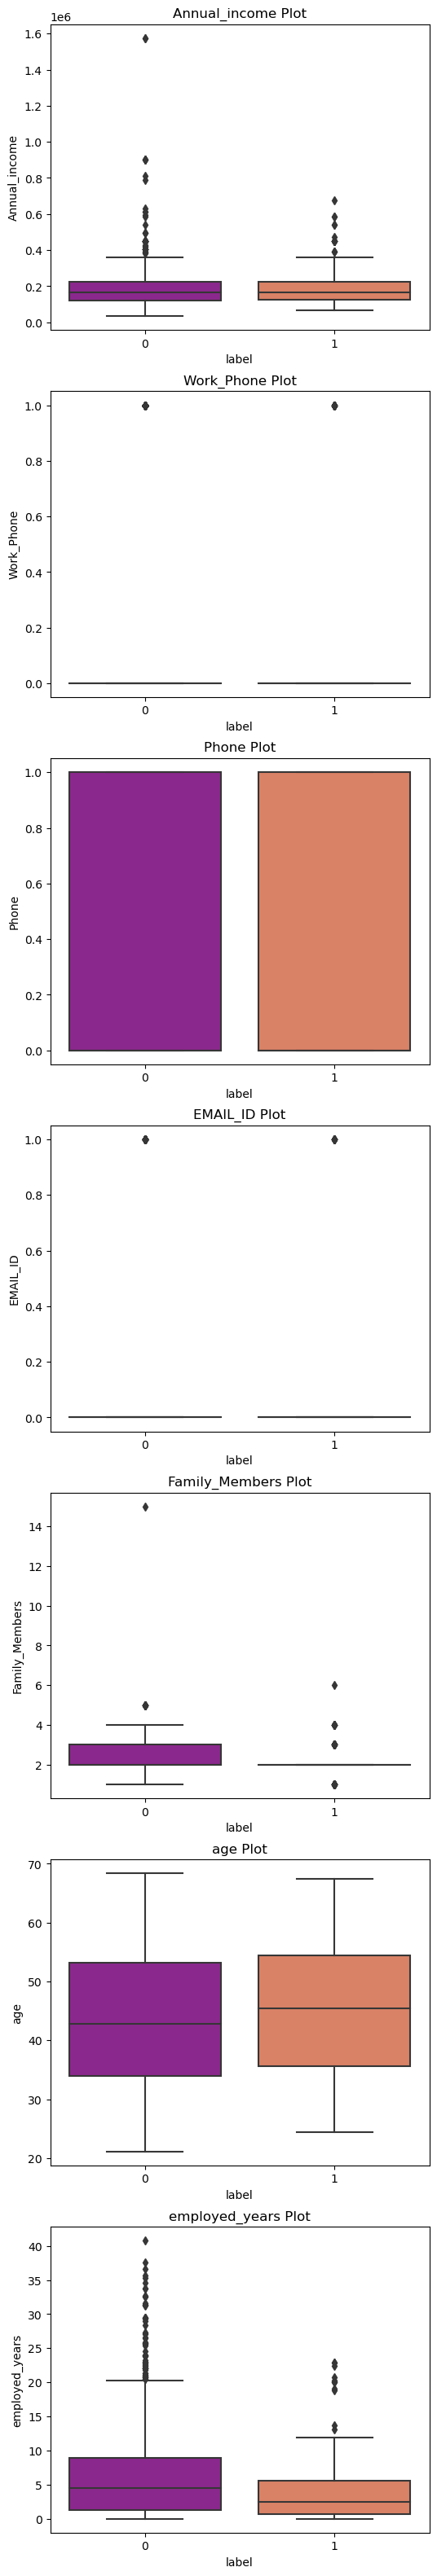

In [24]:
cols=df_numerical.columns
cols=[c for c in cols if c!='label']
l=len(cols)
plt.figure(figsize=(6,40))
for i in range(l):
    plt.subplot(l,1,i+1)
    sns.boxplot(x=df.label,y=df[cols[i]],palette=("plasma"))
    plt.title(cols[i]+' Plot')
plt.show()

## Data Scaling and Dummy Variables 

Scaling numerical Columns

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df[numerical_variables]=scaler.fit_transform(df[numerical_variables])

Dummy Variables for categorical Columns

In [26]:
l=len(categorical_variables)

for i in range(l):
    temp=pd.get_dummies(df[categorical_variables[i]],drop_first=True,prefix=categorical_variables[i],prefix_sep='_')
    df=pd.concat([df,temp],axis=1)
    df.drop(categorical_variables[i],axis=1,inplace=True)
    

In [27]:
df.head()

,Annual_income,Work_Phone,Phone,EMAIL_ID,Family_Members,label,age,employed_years,GENDER_Gender_Missing,GENDER_M,...,Type_Occupation_Low-skill Laborers,Type_Occupation_Managers,Type_Occupation_Medicine staff,Type_Occupation_Private service staff,Type_Occupation_Realty agents,Type_Occupation_Sales staff,Type_Occupation_Secretaries,Type_Occupation_Security staff,Type_Occupation_Type_Occupation_Missing,Type_Occupation_Waiters/barmen staff
0,0.094891,0.0,0.0,0.0,0.071429,1.0,0.641900,0.000000,0,1,...,0,0,0,0,0,0,0,0,1,0
1,0.182482,1.0,1.0,0.0,0.071429,1.0,0.339423,0.039363,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0.182482,1.0,1.0,0.0,0.071429,1.0,0.461487,0.039363,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0.086131,1.0,1.0,0.0,0.071429,1.0,0.339423,0.039363,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0.182482,1.0,1.0,0.0,0.071429,1.0,0.339423,0.039363,0,0,...,0,0,0,0,0,0,0,0,1,0


## Train test Split

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
np.random.seed(20)

In [30]:
df_train,df_test=train_test_split(df,train_size=0.7,test_size=0.3,random_state=100)

In [31]:
y_train=df_train.pop('label')
x_train=df_train

In [32]:
y_test=df_test.pop('label')
x_test=df_test

## Model Building

In [33]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix,roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### No pruning

In [34]:
# Defining the variables
x_train_np=x_train
y_train_np=y_train
x_test_np=x_test
y_test_np=y_test

In [35]:
clf_np=DecisionTreeClassifier(random_state=0)
a_np=clf_np.fit(x_train_np,y_train_np)

In [36]:
print(clf_np)

DecisionTreeClassifier(random_state=0)


In [37]:
y_train_np_pred = clf_np.predict(x_train_np)
y_test_np_pred = clf_np.predict(x_test_np)

In [38]:
print('No Pruning')
print('Train AUC score '+ str(roc_auc_score(y_train_np_pred,y_train_np)))
print("Test AUC score "+str(roc_auc_score(y_test_np_pred,y_test_np)))
#plot_confusionmatrix(y_train_np_pred,y_train_np,dom='Train')
#plot_confusionmatrix(y_test_np_pred,y_test_np,dom='Test')

No Pruning
Train AUC score 0.992587276682238
Test AUC score 0.6989739220625277


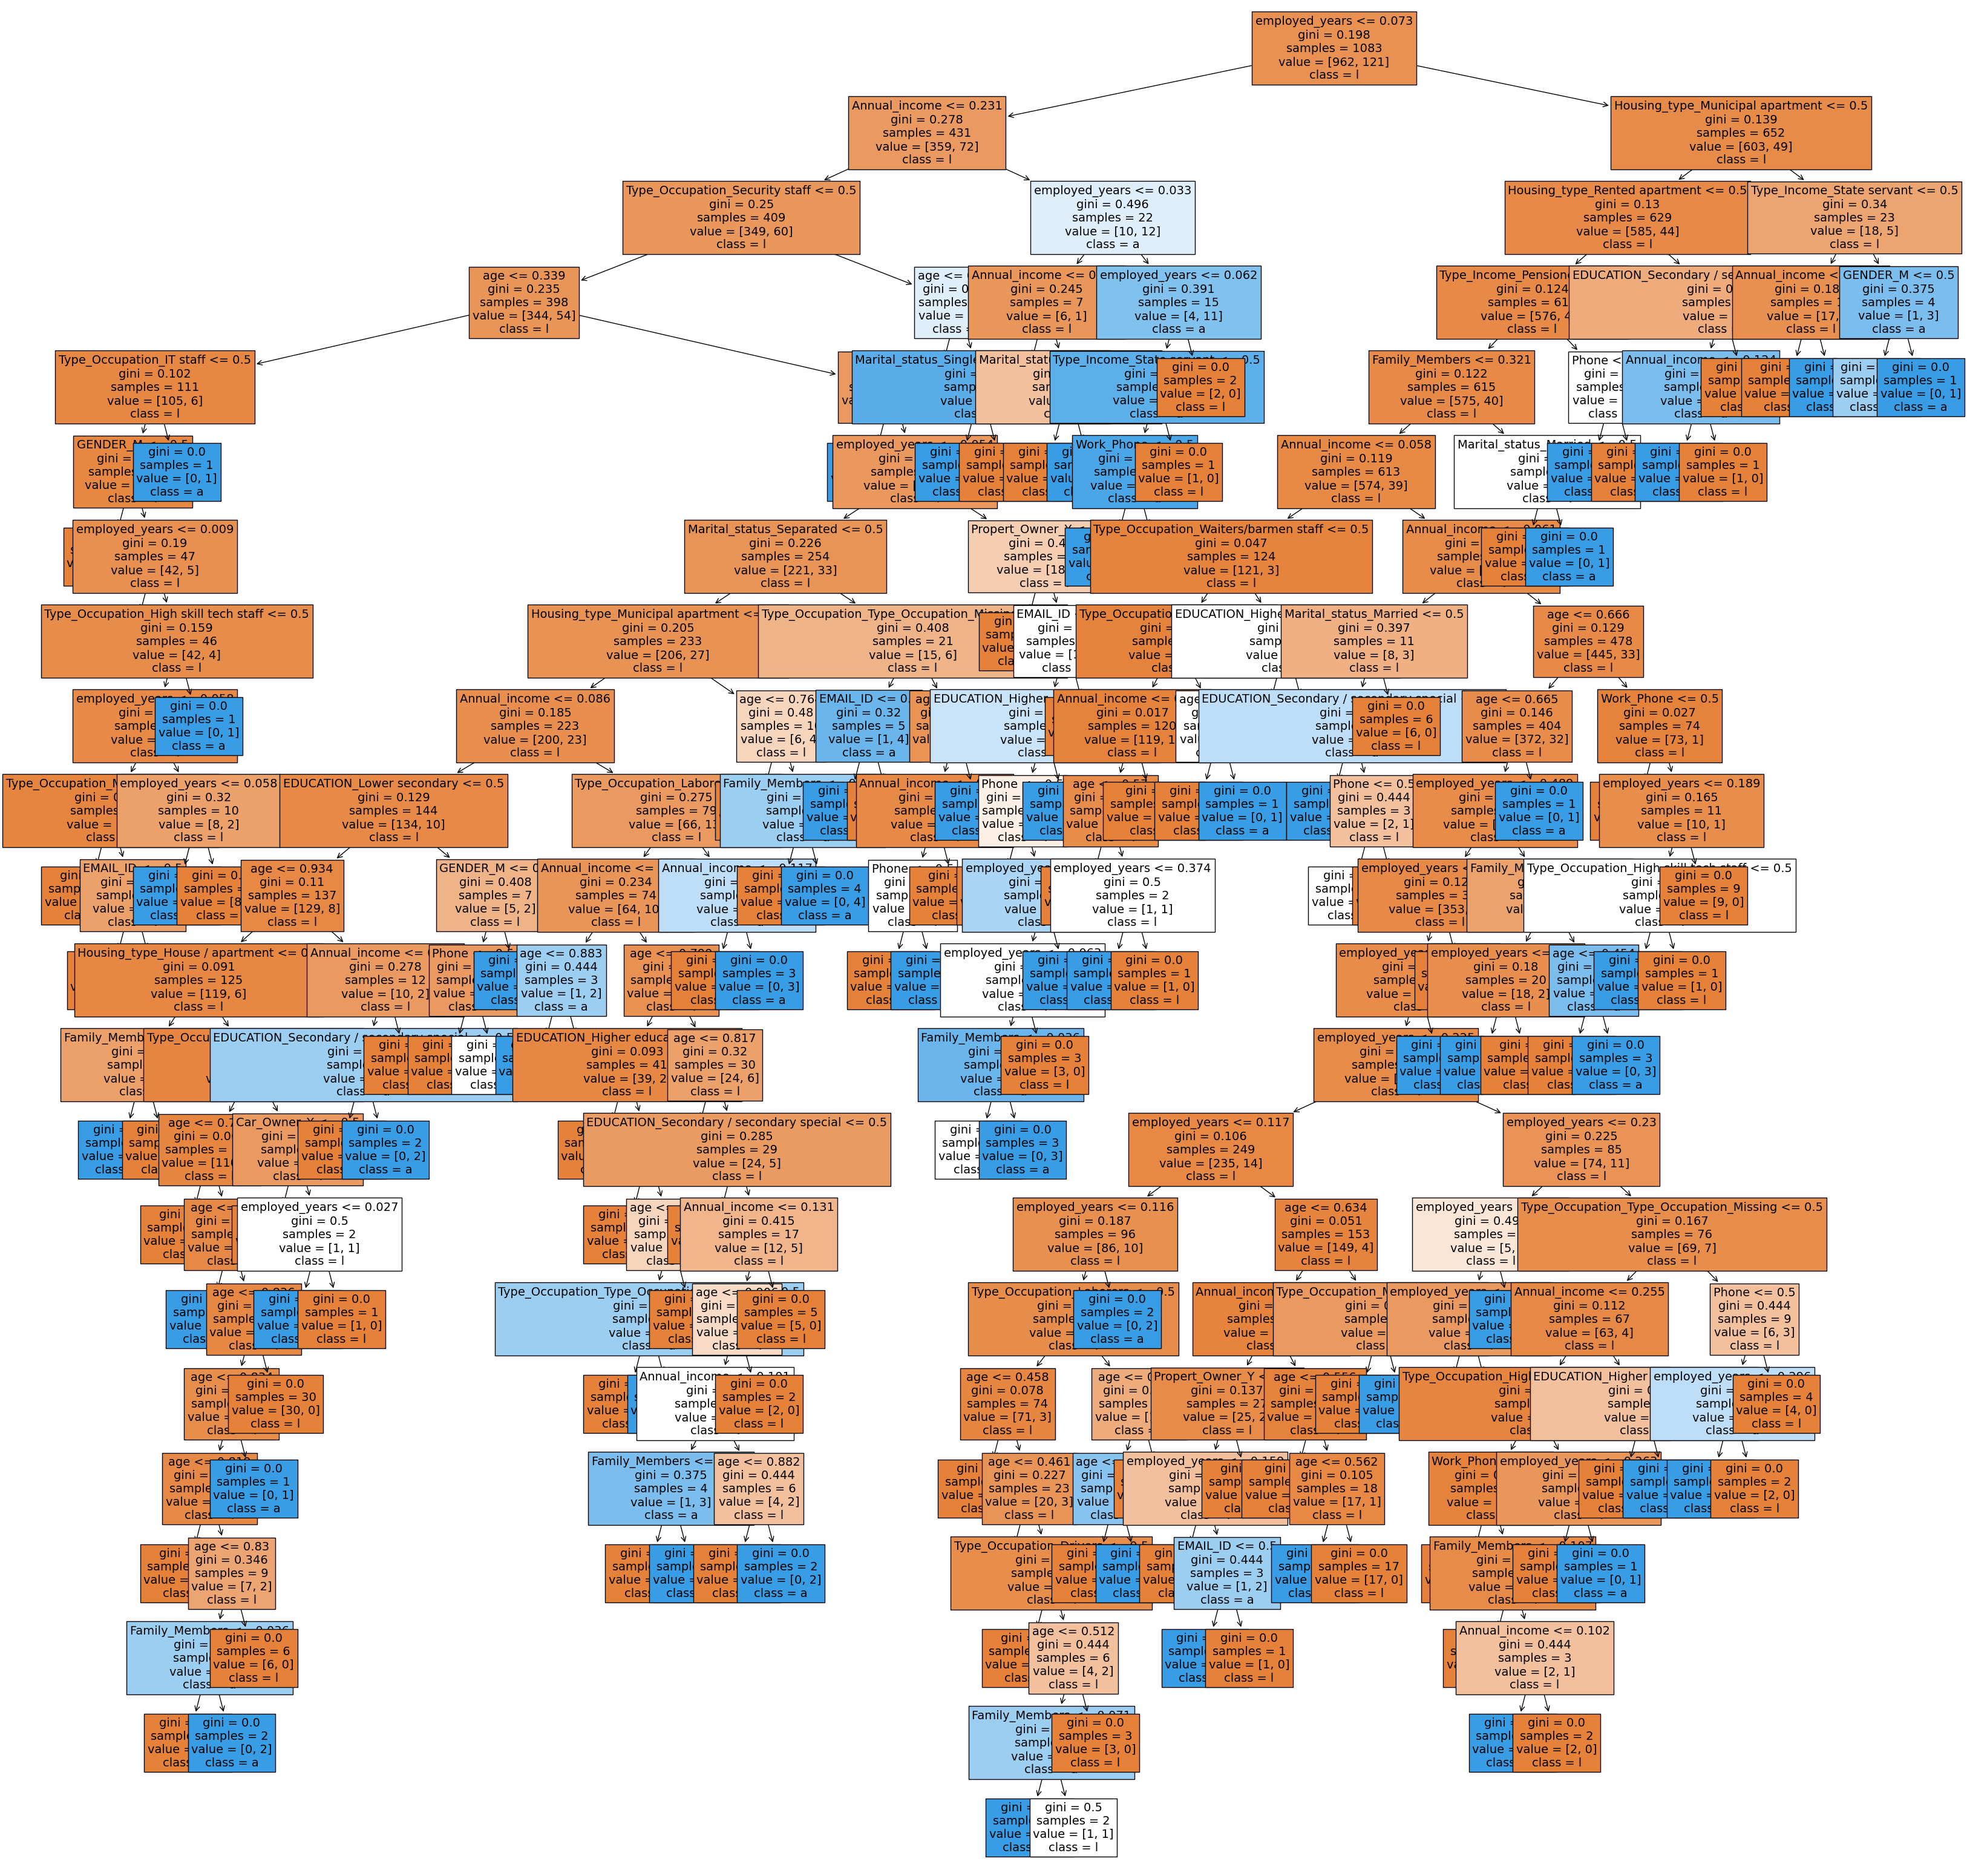

In [39]:
# Plotting the decision tree for no Pruning case
plt.figure(figsize=(40,40))
plot_tree(clf_np, filled=True, feature_names=x_train_np.columns, class_names=y_train_np.name,fontsize=14)
plt.show()

### Pre- pruning

In [40]:
x_train_pre=x_train
y_train_pre=y_train
x_test_pre=x_test
y_test_pre=y_test

In [41]:
params = {'max_depth': [2,4,6,8,10,12,14,16,18,20,22,21],
         'min_samples_split': [10,15,20,25,30,1],
         'min_samples_leaf': [5,10,15,20,1]}

clf_pre = DecisionTreeClassifier()
gcv = GridSearchCV(estimator=clf_pre,param_grid=params,cv=5,scoring='roc_auc')
gcv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22,
                                       21],
                         'min_samples_leaf': [5, 10, 15, 20, 1],
                         'min_samples_split': [10, 15, 20, 25, 30, 1]},
             scoring='roc_auc')

In [1]:
model_pre = gcv.best_estimator_
model_pre.fit(x_train_pre,y_train_pre)
y_train_pre_pred = model_pre.predict(x_train_pre)
y_test_pre_pred = model_pre.predict(x_test_pre)
print(model_pre)

NameError: name 'gcv' is not defined

In [43]:
print('Pre-Pruning')
print(f'Train AUC score {roc_auc_score(y_train_pre_pred,y_train_pre)}')
print(f'Test AUC score {roc_auc_score(y_test_pre_pred,y_test_pre)}')
#plot_confusionmatrix(y_train_pred,y_train,dom='Train')
#plot_confusionmatrix(y_test_pred,y_test,dom='Test')

Pre-Pruning


NameError: name 'y_train_pre_pred' is not defined

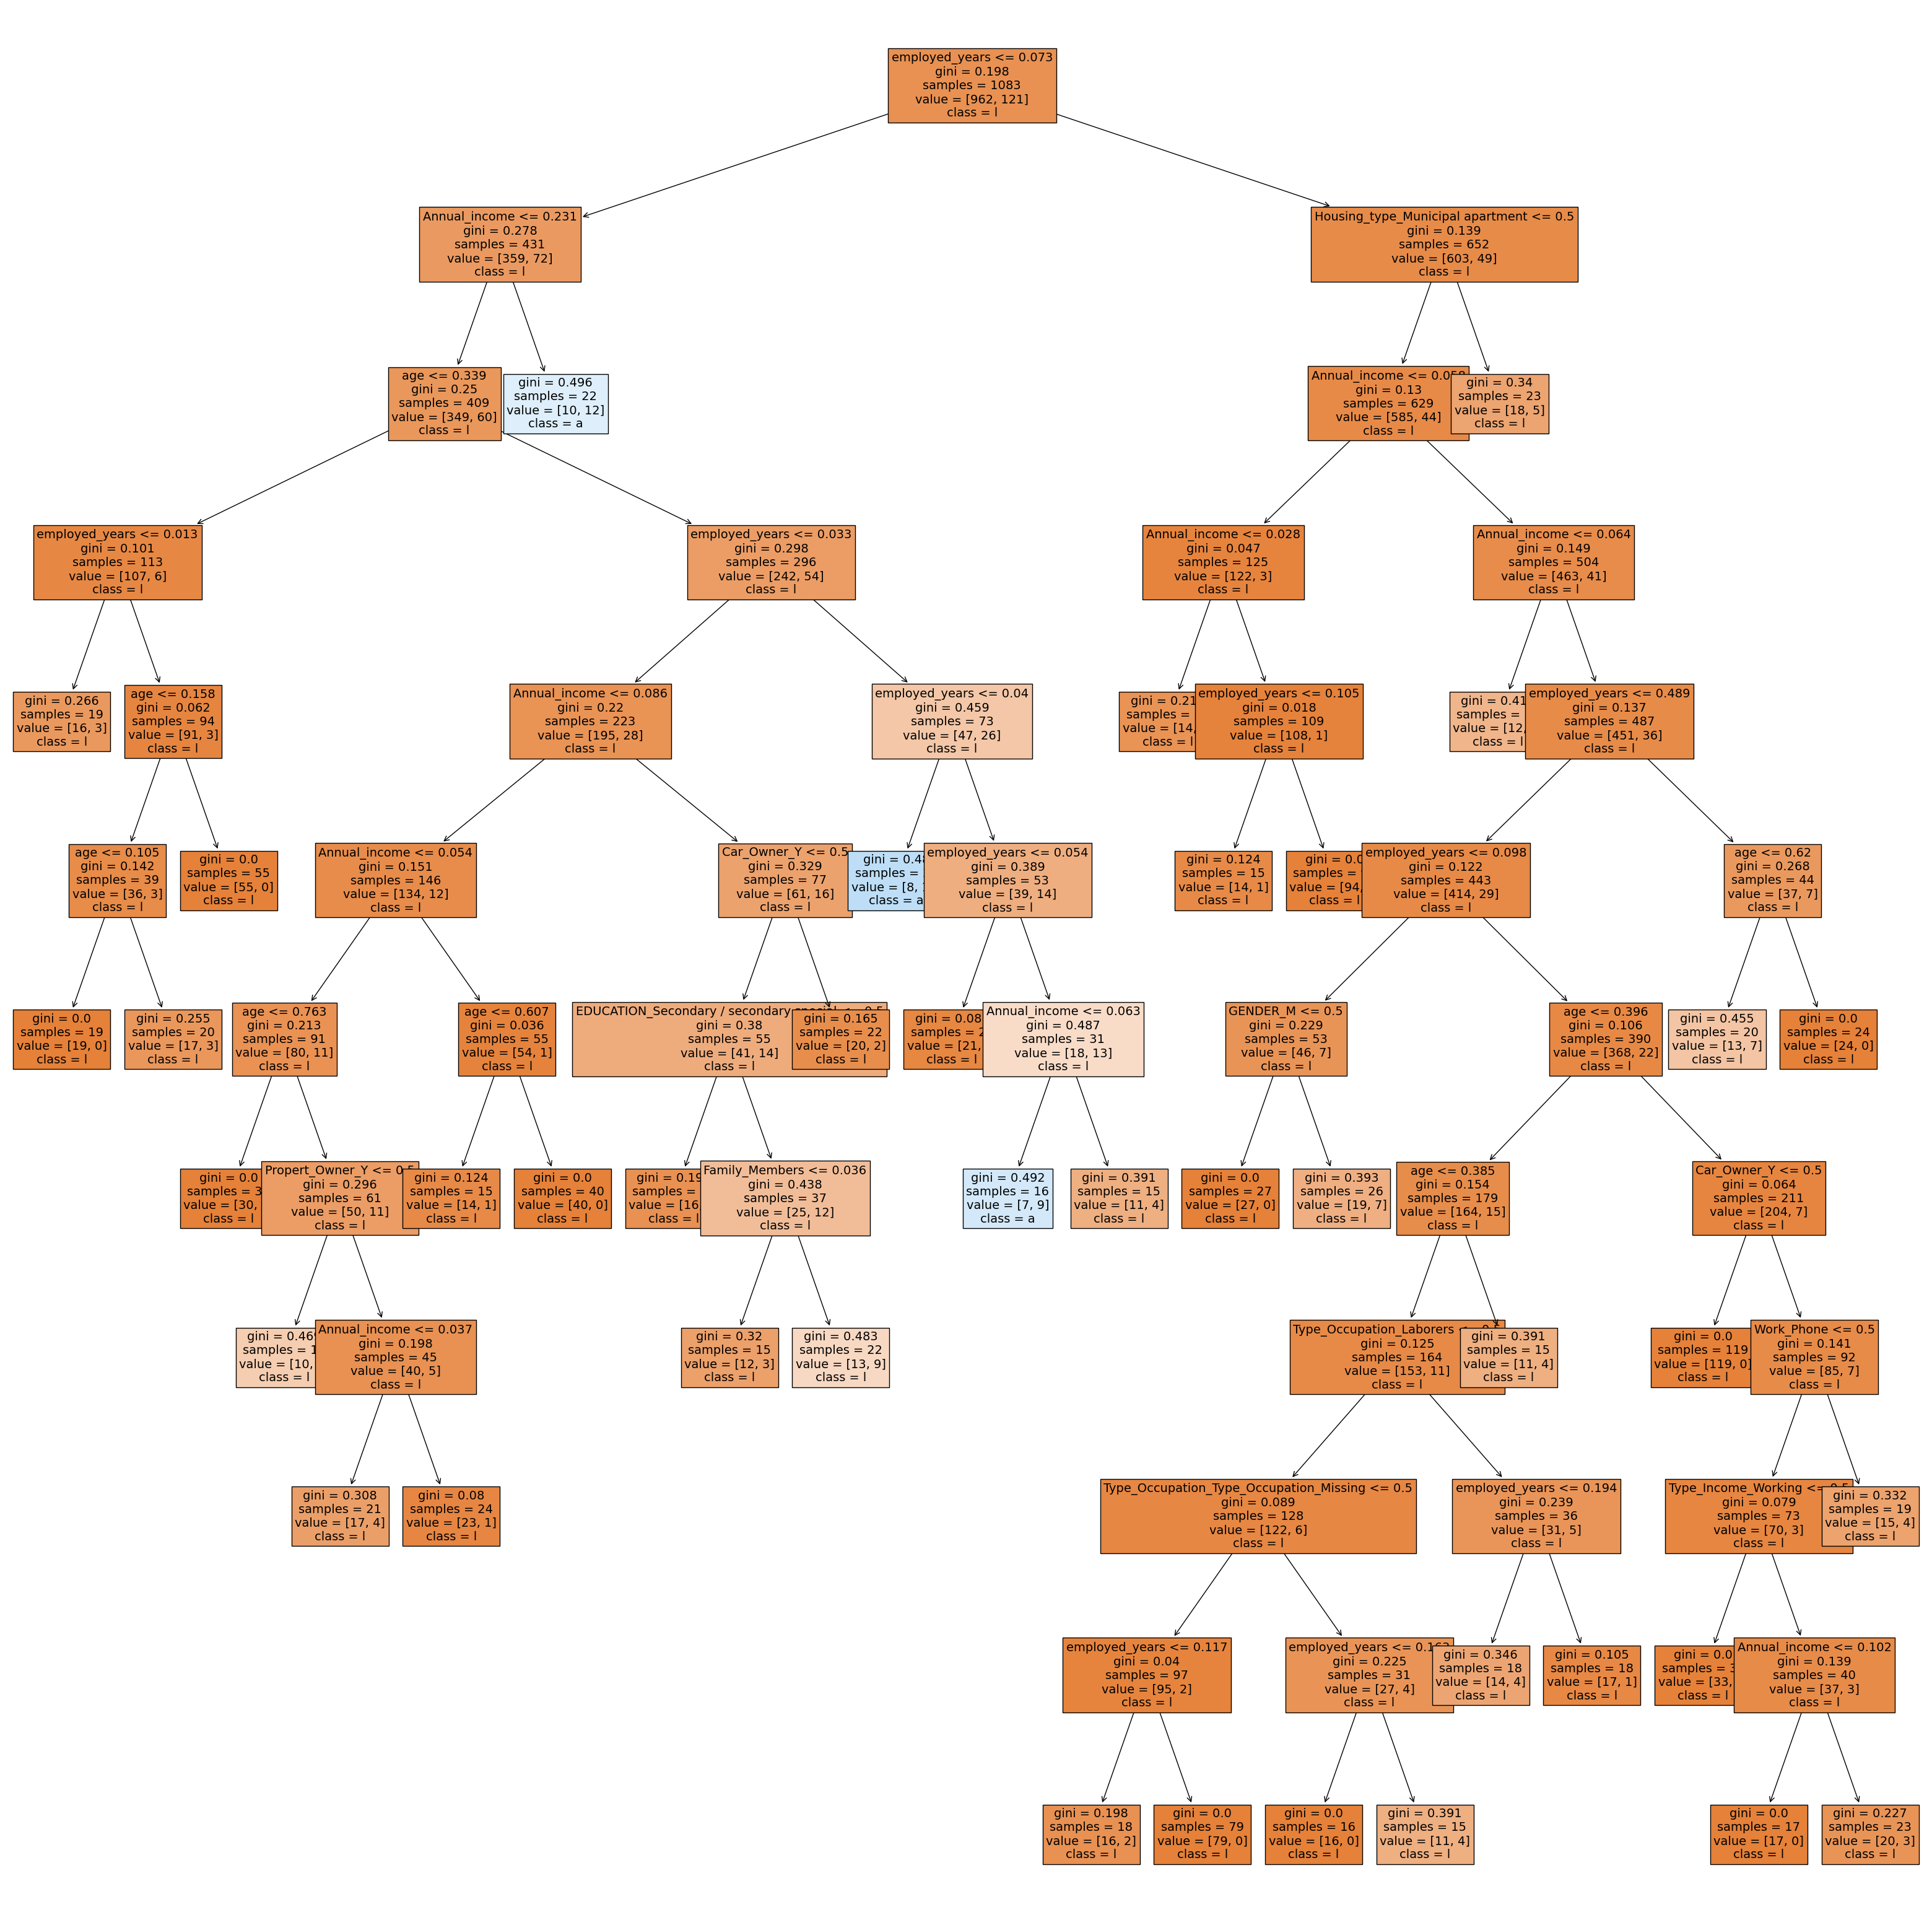

In [44]:
# Plotting the decision tree for Pre-Pruning case
plt.figure(figsize=(40,40))
plot_tree(model_pre, filled=True, feature_names=x_train_pre.columns, class_names=y_train_pre.name,fontsize=14)
plt.show()

### Post Pruning

In [45]:
# splitting the data into test,train and validation sets
df_trainval,df_test_post = train_test_split(df, test_size=0.3, random_state=100)
df_train_post,df_val_post = train_test_split(df_trainval, test_size=0.1, random_state=100)

In [46]:
y_train_post=df_train_post.pop('label')
x_train_post=df_train_post
y_test_post=df_test_post.pop('label')
x_test_post=df_test_post
y_val_post=df_val_post.pop('label')
x_val_post=df_val_post

In [47]:
clf_post=DecisionTreeClassifier()
clf_post.fit(x_train_post,y_train_post)

DecisionTreeClassifier()

In [48]:
path = clf_post.cost_complexity_pruning_path(x_train_post, y_train_post)

In [49]:
print(pd.DataFrame(path).head())

   ccp_alphas  impurities
0    0.000000    0.007529
1    0.000342    0.007871
2    0.000428    0.008299
3    0.000481    0.009262
4    0.000513    0.009775


In [50]:
ccp_alphas, impurities = path.ccp_alphas, path.impurities
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(x_train, y_train)
    clfs.append(clf)
print(pd.DataFrame(clfs).head())

                                                   0
0             DecisionTreeClassifier(random_state=0)
1  DecisionTreeClassifier(ccp_alpha=0.00034223134...
2  DecisionTreeClassifier(ccp_alpha=0.00042778918...
3  DecisionTreeClassifier(ccp_alpha=0.00048126283...
4  DecisionTreeClassifier(ccp_alpha=0.00051334702...


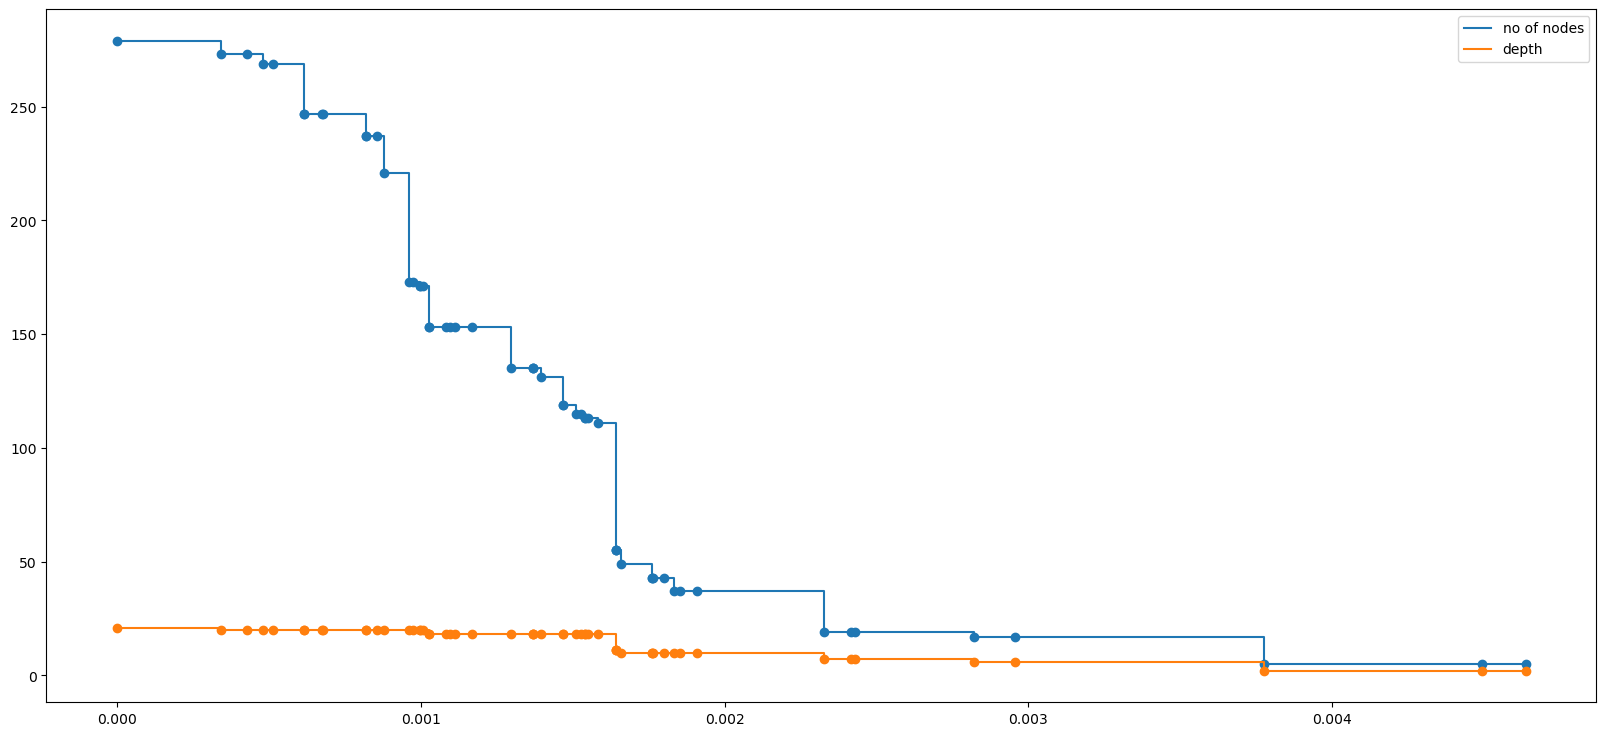

In [51]:
# to check if the decision tree becomes less complex with increasing alpha
node_count=[ clf.tree_.node_count for clf in clfs]
depth=[ clf.tree_.max_depth for clf in clfs]

plt.figure(figsize=(20,9))
plt.scatter(ccp_alphas,node_count)
plt.scatter(ccp_alphas,depth)
plt.plot(ccp_alphas,node_count,label='no of nodes',drawstyle="steps-post")
plt.plot(ccp_alphas,depth,label='depth',drawstyle="steps-post")
plt.legend()
plt.show()

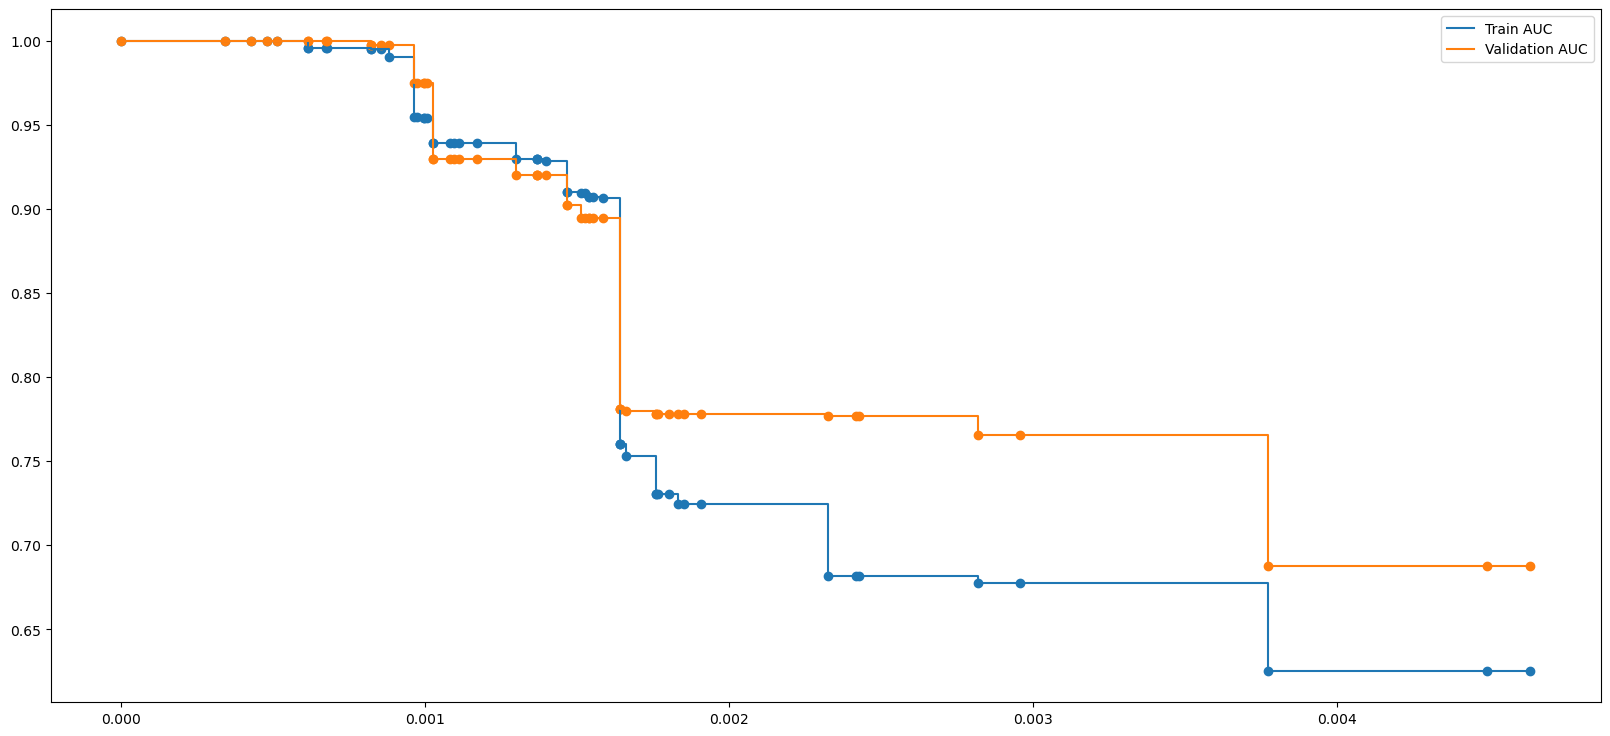

In [52]:
#to check the accuracy of different alpha on the validation set and deciding on the alpha to use

train_post_acc = []
val_post_acc = []

for c in clfs:
    y_train_prob = c.predict_proba(x_train_post)[:, 1]
    y_val_prob   = c.predict_proba(x_val_post)[:, 1]
    train_post_acc.append(roc_auc_score(y_train_post,y_train_prob))
    val_post_acc.append(roc_auc_score(y_val_post,y_val_prob))
    
plt.figure(figsize=(20,9))
plt.scatter(ccp_alphas,train_post_acc)
plt.scatter(ccp_alphas,val_post_acc)
plt.plot(ccp_alphas,train_post_acc,label='Train AUC',drawstyle="steps-post")
plt.plot(ccp_alphas,val_post_acc,label='Validation AUC',drawstyle="steps-post")
plt.legend()
plt.show()

In [53]:
ba = pd.DataFrame({
    'ccp_alphas': ccp_alphas,
    'val_post_acc': val_post_acc
})
best_alpha=ba.loc[ba['val_post_acc']==ba['val_post_acc'].max()] #['ccp_alphas']
print(best_alpha)

   ccp_alphas  val_post_acc
0    0.000000           1.0
1    0.000342           1.0
2    0.000428           1.0
3    0.000481           1.0
4    0.000513           1.0
5    0.000616           1.0
6    0.000616           1.0
7    0.000675           1.0
8    0.000677           1.0


From here, the alpha=0 will be fit 

In [54]:
clf_post = DecisionTreeClassifier(random_state=0,ccp_alpha=0)
clf_post.fit(x_train_post,y_train_post)
y_train_post_pred = clf_post.predict(x_train_post)
y_test_post_pred = clf_post.predict(x_test_post)

print(f'Train score {roc_auc_score(y_train_post_pred,y_train_post)}')
print(f'Test score {roc_auc_score(y_test_post_pred,y_test_post)}')

Train score 0.9919823232323234
Test score 0.6511608841083492
